In [1]:
import fdfi
print('FDFI version:', fdfi.__version__)

FDFI version: 0.0.9


# OTExplainer: Gaussian Optimal Transport

This tutorial provides a deep dive into the `OTExplainer`, which uses Gaussian optimal transport for computing feature importance.

## What You'll Learn

1. Mathematical foundation of Gaussian OT
2. Key hyperparameters and their effects
3. When to use OTExplainer vs other methods
4. Best practices for real-world usage

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fdfi.explainers import OTExplainer
from fdfi.plots import correlation_heatmap, diagnostics_plot, summary_bar

np.random.seed(42)

## Mathematical Background

The key insight of OTExplainer is to use the **Gaussian optimal transport map** to create counterfactual distributions.

Given data $X$ with mean $\mu$ and covariance $\Sigma$, we compute:

$$Z = L^{-1}(X - \mu)$$

where $\Sigma = LL^T$ (Cholesky decomposition). In Z-space, features are uncorrelated.

To measure the importance of feature $j$, we:
1. Replace $Z_j$ with an independent sample from $N(0, 1)$
2. Transform back to X-space
3. Compare model outputs

## Setup: Create Correlated Data

Let's create data with correlated features to see how OTExplainer handles dependencies:

In [3]:
# Create covariance matrix with correlations
n_features = 5
correlation = 0.7

cov_matrix = np.eye(n_features)
cov_matrix[0, 1] = cov_matrix[1, 0] = correlation  # Features 0 and 1 are correlated
cov_matrix[2, 3] = cov_matrix[3, 2] = correlation  # Features 2 and 3 are correlated

# Generate correlated data
n_samples = 500
X_train = np.random.multivariate_normal(
    mean=np.zeros(n_features),
    cov=cov_matrix,
    size=n_samples
)

print("Correlation matrix of training data:")
print(np.corrcoef(X_train.T).round(2))

Correlation matrix of training data:
[[ 1.    0.71 -0.03 -0.   -0.05]
 [ 0.71  1.    0.02  0.03 -0.06]
 [-0.03  0.02  1.    0.72 -0.02]
 [-0.    0.03  0.72  1.   -0.  ]
 [-0.05 -0.06 -0.02 -0.    1.  ]]


In [4]:
# Create model: only feature 0 matters
def model(X):
    return X[:, 0] ** 2

# Test data
X_test = np.random.multivariate_normal(
    mean=np.zeros(n_features),
    cov=cov_matrix,
    size=50
)

## Effect of nsamples

The `nsamples` parameter controls Monte Carlo variance. Let's see its effect:

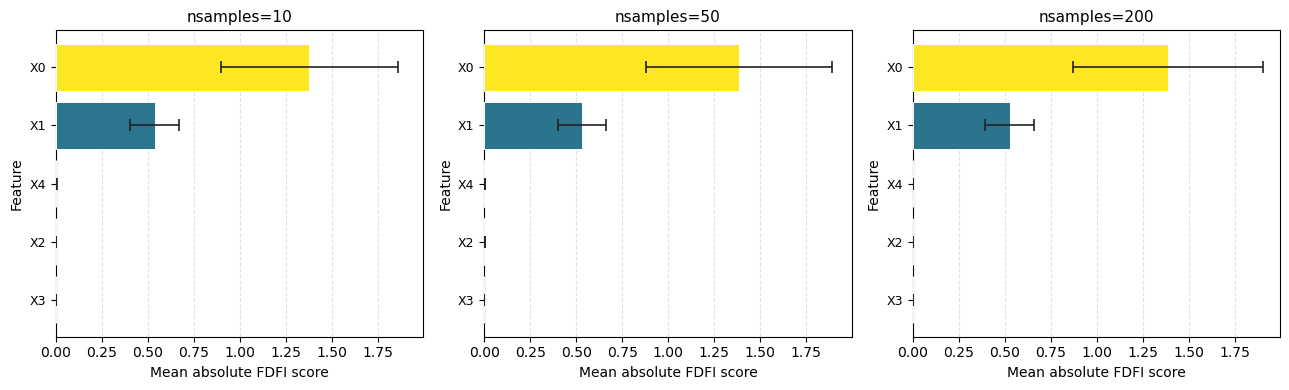

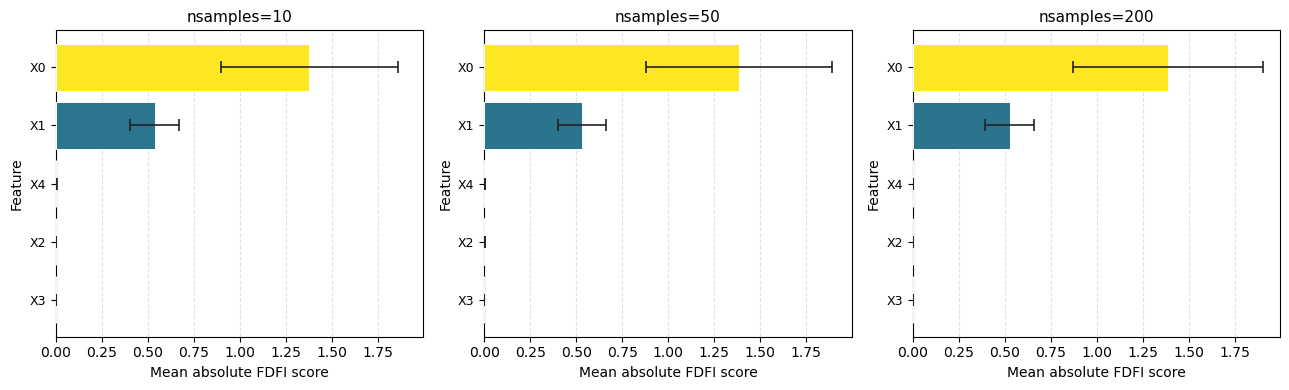

In [5]:
# Compare different nsamples values
nsamples_values = [10, 50, 200]
results_by_nsamples = {}
feature_names = [f"X{i}" for i in range(n_features)]

for ns in nsamples_values:
    explainer = OTExplainer(model, data=X_train, nsamples=ns)
    results_by_nsamples[ns] = explainer(X_test)

fig, axes = plt.subplots(1, len(nsamples_values), figsize=(13, 4), sharex=True)
for ax, ns in zip(axes, nsamples_values):
    summary_bar(
        results_by_nsamples[ns]["phi_X"],
        results_by_nsamples[ns]["se_X"],
        feature_names,
        ax=ax,
        show=False,
        title=f"nsamples={ns}",
        max_display=n_features,
    )
fig

**Key observation**: Higher `nsamples` gives smaller error bars (lower variance) but takes longer to compute.

## Effect of sampling_method

OTExplainer supports three sampling methods for counterfactual generation:

In [6]:
# Compare sampling methods
sampling_methods = ["resample", "permutation", "normal"]
results_by_method = {}

for method in sampling_methods:
    explainer = OTExplainer(
        model, 
        data=X_train, 
        nsamples=100,
        sampling_method=method
    )
    results_by_method[method] = explainer(X_test)

# Compare results
print("Feature importance by sampling method:")
print("-" * 50)
print(f"{'Feature':>8}", end="")
for method in sampling_methods:
    print(f"{method:>12}", end="")
print()
print("-" * 50)

for i in range(n_features):
    print(f"{i:>8}", end="")
    for method in sampling_methods:
        phi = results_by_method[method]["phi_X"][i]
        print(f"{phi:>12.4f}", end="")
    print()

Feature importance by sampling method:
--------------------------------------------------
 Feature    resample permutation      normal
--------------------------------------------------
       0      1.3690      1.3081      1.3115
       1      0.5196      0.5108      0.5431
       2      0.0020      0.0020      0.0019
       3      0.0003      0.0003      0.0003
       4      0.0030      0.0029      0.0030


**Sampling methods explained:**

- `resample`: Sample from the background data (preserves marginal distribution)
- `permutation`: Permute values within test set (no new values introduced)
- `normal`: Sample from standard normal (strongest Gaussian assumption)

## Visualizing the Z-space Transformation

Let's visualize how OTExplainer transforms correlated data to uncorrelated Z-space:

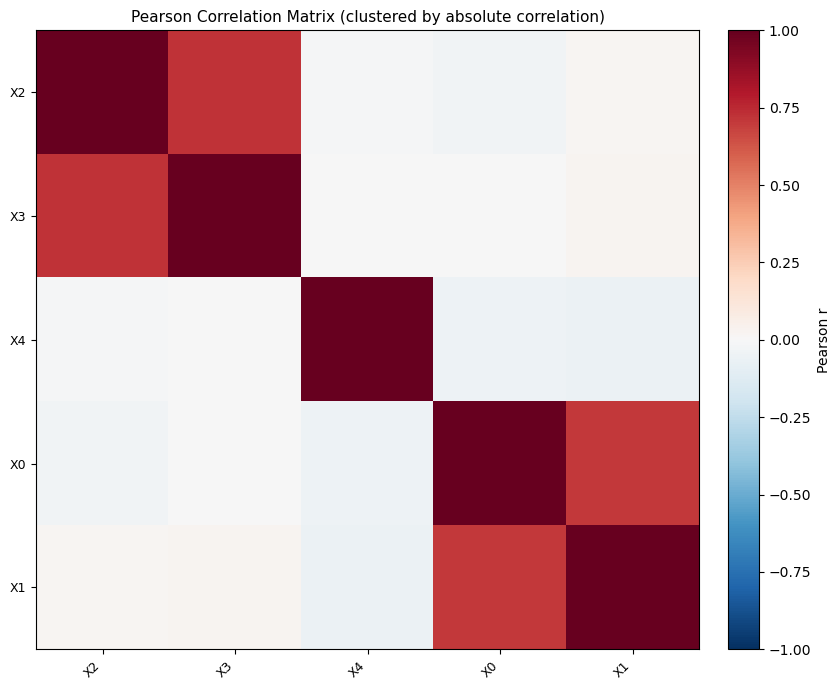

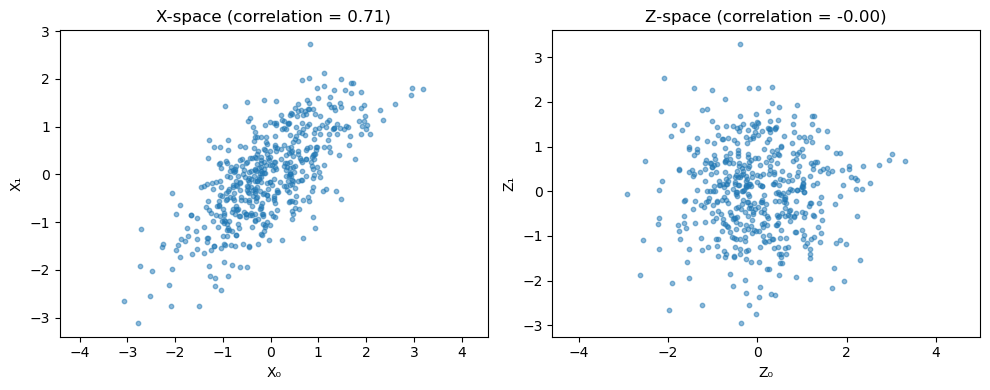

In [7]:
# Create explainer and access internal matrices
explainer = OTExplainer(model, data=X_train, nsamples=50)
feature_names = [f"X{i}" for i in range(n_features)]

# Background feature correlation before whitening
correlation_heatmap(X_train, feature_names, show=False)

# Transform to Z-space
Z_train = (X_train - explainer.mean) @ explainer.L_inv

# Plot X-space vs Z-space
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# X-space (correlated)
axes[0].scatter(X_train[:, 0], X_train[:, 1], alpha=0.5, s=10)
axes[0].set_xlabel("X₀")
axes[0].set_ylabel("X₁")
axes[0].set_title(f"X-space (correlation = {np.corrcoef(X_train[:, 0], X_train[:, 1])[0, 1]:.2f})")
axes[0].axis('equal')

# Z-space (uncorrelated)
axes[1].scatter(Z_train[:, 0], Z_train[:, 1], alpha=0.5, s=10)
axes[1].set_xlabel("Z₀")
axes[1].set_ylabel("Z₁")
axes[1].set_title(f"Z-space (correlation = {np.corrcoef(Z_train[:, 0], Z_train[:, 1])[0, 1]:.2f})")
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## Shared Diagnostics and Summary

Use the built-in diagnostics and `summary()` methods for consistent reporting
across OT/EOT/Flow explainers.


OT diagnostics
--------------------------------------------------
Latent independence (median dCor): 0.066532 [GOOD]
Distribution fidelity (MMD):       0.000000 [GOOD]

X-space summary
Feature Importance Results
Method: OTExplainer
Number of units: 5
Significance level: 0.05
Alternative: greater
Margin method: gap
Practical margin: 0.0031
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     1.3843     0.5065     0.5511        inf     0.0032   ***
              1     0.5322     0.1313     0.3163        inf     0.0000   ***
              2     0.0020     0.0026    -0.0023        inf     0.6592      
              3     0.0003     0.0026    -0.0039        inf     0.8615      
              4     0.0031     0.0027    -0.0013        inf     0.5000      
Significant units: 2 / 5
---
Signif. co

(<Figure size 1000x400 with 3 Axes>,
 array([<Axes: title={'center': 'FDFI Diagnostics'}, ylabel='Diagnostic value'>,
        <Axes: title={'center': 'Latent dCor Matrix'}>], dtype=object))

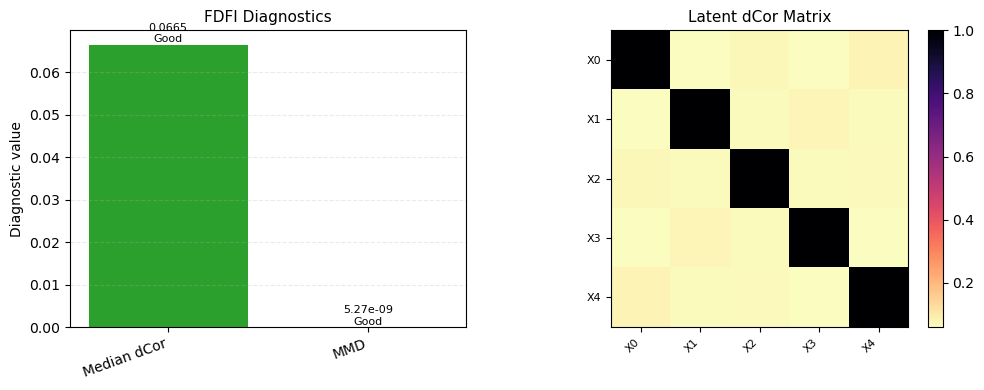

In [8]:
_ = explainer(X_test)
diag = explainer.diagnostics
print("OT diagnostics")
print("-" * 50)
print(f"Latent independence (median dCor): {diag['latent_independence_median']:.6f} [{diag['latent_independence_label']}]")
print(f"Distribution fidelity (MMD):       {diag['distribution_fidelity_mmd']:.6f} [{diag['distribution_fidelity_label']}]")

print("\nX-space summary")
_ = explainer.summary(alpha=0.05, target='X', alternative='greater')


diagnostics_plot(diag, feature_names=feature_names, show=False)


## Best Practices

### When to use OTExplainer

✅ **Good for:**
- Continuous features
- Roughly Gaussian data
- Fast computation
- Stable results

❌ **Consider EOTExplainer for:**
- Heavily non-Gaussian data
- Multimodal distributions
- Mixed categorical/continuous features

### Recommended settings

```python
explainer = OTExplainer(
    model,
    data=X_train,
    nsamples=50,               # Good balance of speed/accuracy
    sampling_method="resample", # Preserves marginal distribution
)
```

## Summary

Key takeaways:

1. OTExplainer uses Gaussian OT to disentangle correlated features.
2. Higher `nsamples` reduces variance at the cost of computation time.
3. `sampling_method="resample"` is recommended for most cases.
4. The transformation to Z-space removes correlations for clean attribution.
5. Shared diagnostics and `summary()` provide standardized inference reporting.
